# Лабораторная работа №3: Линейная регрессия


Цель работы — построить и проанализировать несколько моделей линейной регрессии, которые прогнозируют **индекс успеваемости** студента на основе различных факторов (часы учебы, предыдущие оценки, занятия вне учебы и т.д.).

ТЗ:

1. Выполнить первичный анализ данных (описательная статистика и графики).
2. Провести предварительную обработку данных, включая работу с пропущенными значениями, кодирование категорий и нормировку признаков.
3. Разделить данные на обучающую и тестовую выборки.
4. Реализовать линейную регрессию методом наименьших квадратов **вручную** (без `sklearn`).
5. Построить **три модели** с различными наборами признаков.
6. Для каждой модели оценить качество по коэффициенту детерминации $R^2$ и сравнить результаты.
7. Сформулировать выводы о том, какие признаки оказываются наиболее полезными.


## Шаг 1. Импорт библиотек и загрузка данных


In [6]:
import math
from typing import List, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (8, 5)

DATA_PATH = 'lab3.csv'

df = pd.read_csv(DATA_PATH)
print(df.shape)
df.head()

(10000, 6)


,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0


## Шаг 2. Первичный анализ и описательная статистика

Изучаем датасет:

- количество строк и столбцов;
- типы данных по каждому столбцу;
- основные числовые характеристики (минимум, максимум, среднее, стандартное отклонение, квартили);
- распределение категориальных признаков.

Стандартное отклонение (standard deviation) — это мера разброса данных относительно среднего значения. Показывает насколько сильно значения признака варьируются.
Квартили (quartiles) — это значения, которые делят отсортированные данные на четыре равные части. Показывает как распределены данные без влияния выбросов.

In [7]:

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Hours Studied                     10000 non-null  int64  
 1   Previous Scores                   10000 non-null  int64  
 2   Extracurricular Activities        10000 non-null  object 
 3   Sleep Hours                       10000 non-null  int64  
 4   Sample Question Papers Practiced  10000 non-null  int64  
 5   Performance Index                 10000 non-null  float64
dtypes: float64(1), int64(4), object(1)
memory usage: 468.9+ KB


In [8]:

df.describe().T

,count,mean,std,min,25%,50%,75%,max
Hours Studied,10000.0,4.9929,2.589309,1.0,3.0,5.0,7.0,9.0
Previous Scores,10000.0,69.4457,17.343152,40.0,54.0,69.0,85.0,99.0
Sleep Hours,10000.0,6.5306,1.695863,4.0,5.0,7.0,8.0,9.0
Sample Question Papers Practiced,10000.0,4.5833,2.867348,0.0,2.0,5.0,7.0,9.0
Performance Index,10000.0,55.2248,19.212558,10.0,40.0,55.0,71.0,100.0


In [9]:
df['Extracurricular Activities'].value_counts()

Extracurricular Activities
No     5052
Yes    4948
Name: count, dtype: int64

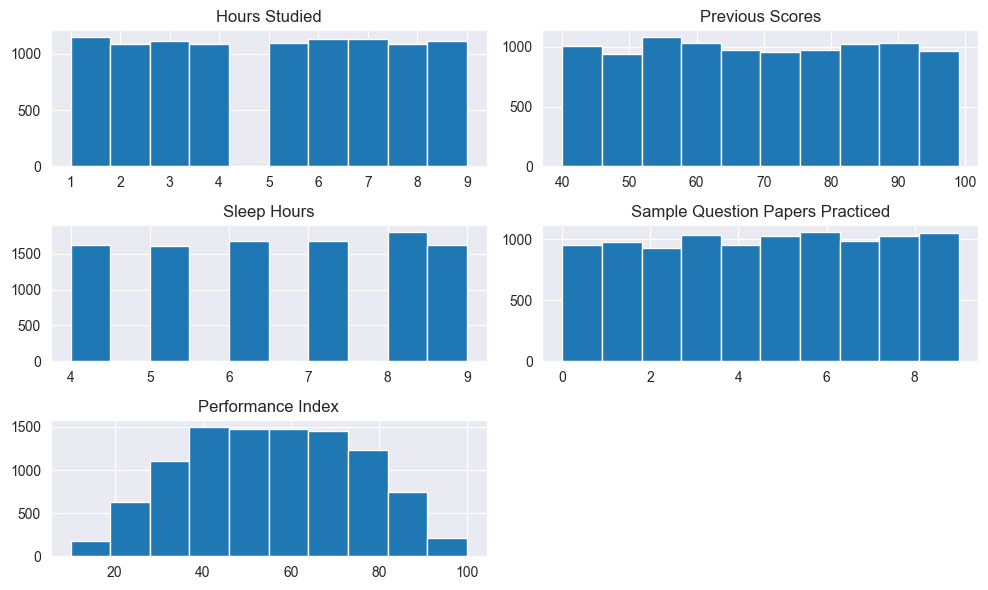

In [10]:
numeric_cols = ['Hours Studied', 'Previous Scores', 'Sleep Hours',
                'Sample Question Papers Practiced', 'Performance Index']

df[numeric_cols].hist(bins=10, figsize=(10, 6))
plt.tight_layout()
plt.show()

Первичный анализ данных показывает, что датасет является полным и не содержит пропущенных значений — все 10 000 строк заполнены по каждому признаку. Типы данных корректные: числовые признаки представлены целыми или вещественными значениями, а единственный категориальный признак (Extracurricular Activities) имеет два возможных значения: Yes и No, распределённых практически поровну.

Статистические характеристики позволяют увидеть общие тенденции:

количество часов учебы, сна и решённых примерных заданий лежит в умеренных и ожидаемых диапазонах;

предыдущие оценки имеют широкий разброс (от 40 до 99), что может оказать значимое влияние на итоговую успеваемость;

показатель успеваемости (Performance Index) распределён примерно симметрично, со средним около 55 и стандартным отклонением около 19.

Гистограммы подтверждают равномерный или почти равномерный характер распределений для большинства признаков, что говорит о том, что данные не содержат выраженных выбросов либо аномальных кластеров. Распределение целевой переменной выглядит близким к нормальному, что является благоприятным условием для линейной регрессии.

В целом, данные хорошо структурированы и готовы к дальнейшей предобработке и построению моделей. Наблюдаемые характеристики показывают, что каждый признак обладает достаточной вариативностью, чтобы потенциально объяснять часть изменений в целевой переменной.

## Шаг 3. Предварительная обработка данных

По заданию нужно провести предобработку, которая включает:

- обработку пропущенных значений;
- кодирование категориальных признаков;
- нормировку (масштабирование) числовых признаков.

### 3.1. Проверка пропусков

Сначала я проверяю, есть ли в датасете пропущенные значения. Если бы они были, их пришлось бы либо заполнять (например, средним/медианой), либо удалять строки/столбцы. В нашем случае проверка показывает, есть ли такая проблема.


In [11]:

df.isna().sum()

Hours Studied                       0
Previous Scores                     0
Extracurricular Activities          0
Sleep Hours                         0
Sample Question Papers Practiced    0
Performance Index                   0
dtype: int64

Из вывода видно, есть ли в столбцах пропуски. В этом датасете пропусков нет, поэтому дополнительная обработка отсутствующих значений не требуется, и я могу использовать все объекты как есть.


### 3.2. Кодирование категориального признака

В датасете есть один категориальный признак — `Extracurricular Activities` (участие во внеучебной деятельности: `Yes` / `No`).  
Линейная регрессия работает с числами, поэтому строковые значения нужно перевести в числовой вид.

Кодируем этот признак следующим образом:

- `Yes` → 1  
- `No` → 0  

Это бинарное кодирование (dummy-переменная), которое удобно для моделей и легко интерпретируется: положительный коэффициент при этой переменной будет означать, что участие во внеучебной деятельности **положительно влияет** на индекс успеваемости.


In [13]:
df['Extracurricular_Encoded'] = (df['Extracurricular Activities'] == 'Yes').astype(int)
df[['Extracurricular Activities', 'Extracurricular_Encoded']].head()

,Extracurricular Activities,Extracurricular_Encoded
0,Yes,1
1,No,0
2,Yes,1
3,Yes,1
4,No,0


### 3.3. Масштабирование (нормировка) числовых признаков

Линейная регрессия чувствительна к масштабу признаков: если один признак измеряется десятками, а другой сотнями, коэффициенты будут несопоставимы по величине.  
Чтобы привести признаки к единому масштабу, я использую **стандартизацию** (z-нормировку):

$$
z = \frac{x - \mu}{\sigma},
$$

где $x$ — исходное значение признака, $\mu$ — среднее значение по выборке, $\sigma$ — стандартное отклонение.  
После стандартизации каждый признак будет иметь среднее примерно 0 и стандартное отклонение 1. Это упрощает обучение и интерпретацию модели.


In [14]:
from copy import deepcopy

numeric_features = ['Hours Studied', 'Previous Scores', 'Sleep Hours',
                    'Sample Question Papers Practiced']

df_scaled = deepcopy(df)
feature_means = {}
feature_stds = {}

for col in numeric_features:
    mean = df_scaled[col].mean()
    std = df_scaled[col].std()
    feature_means[col] = mean
    feature_stds[col] = std
    df_scaled[col] = (df_scaled[col] - mean) / std

df_scaled.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index,Extracurricular_Encoded
0,0.775149,1.704090,Yes,1.456132,-1.249691,91.0,1
1,-0.383461,0.723876,No,-1.492220,-0.900937,65.0,0
2,1.161352,-1.063573,Yes,0.276791,-0.900937,45.0,1
3,0.002742,-1.005913,Yes,-0.902549,-0.900937,36.0,1
4,0.775149,0.320259,No,0.866462,0.145326,66.0,0


## Шаг 4. Разделение данных на обучающую и тестовую выборки

Чтобы корректно оценить качество модели, данные нужно разделить на:обучающую выборку — на ней подбираются коэффициенты регрессии и на тестовую выборку - на ней проверяется, насколько хорошо модель обобщает знания на новых данных.

Я случайным образом перемешиваю индексы объектов и выделяю часть под тестовую выборку.


In [15]:
def train_test_split_manual(X: np.ndarray, y: np.ndarray, test_size: float = 0.3, random_state: int = 42
                            ) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    rng = np.random.RandomState(random_state)
    n_samples = len(y)
    indices = np.arange(n_samples)
    rng.shuffle(indices)

    test_n = int(n_samples * test_size)
    test_idx = indices[:test_n]
    train_idx = indices[test_n:]

    return X[train_idx], X[test_idx], y[train_idx], y[test_idx]

## Шаг 5. Теоретическая часть: линейная регрессия и метод наименьших квадратов

Я рассматриваю **множественную линейную регрессию**, в которой целевая переменная $y$ зависит от нескольких факторов $x_1, x_2, \dots, x_p$:

$$
\hat{y} = a + b_1 x_1 + b_2 x_2 + \dots + b_p x_p.
$$

Здесь:

- $\hat{y}$ — прогнозируемое значение (оценка индекса успеваемости);
- $a$ — свободный член (intercept);
- $b_j$ — коэффициенты регрессии, которые показывают, как в среднем изменяется $y$ при изменении $x_j$ на одну единицу (при фиксированных остальных факторах).

В матричной форме модель записывается как:

$$
\mathbf{y} = X \mathbf{b} + \varepsilon,
$$

где

- $\mathbf{y}$ — вектор наблюдений целевой переменной размерности $n \times 1$;
- $X$ — матрица признаков размерности $n \times (p+1)$ (первый столбец — единицы для свободного члена);
- $\mathbf{b}$ — вектор параметров $(a, b_1, \dots, b_p)^T$;
- $\varepsilon$ — вектор случайных ошибок.

### Метод наименьших квадратов (МНК)

Суть МНК: подобрать такие коэффициенты $\mathbf{b}$, чтобы **минимизировать сумму квадратов отклонений** между фактическими значениями $y_i$ и оценками $\hat{y}_i$:

$$
Q(\mathbf{b}) = \sum_{i=1}^{n} (y_i - \hat{y}_i)^2 = \sum_{i=1}^{n} (y_i - (a + b_1 x_{i1} + \dots + b_p x_{ip}))^2.
$$

Решение этой задачи в матричной форме даётся формулой:

$$
\hat{\mathbf{b}} = (X^T X)^{-1} X^T \mathbf{y}.
$$

Именно эту формулу мы реализуем в коде.


In [16]:
class LinearRegressionScratch:

    def __init__(self):
        self.coeffs_ = None  # вектор коэффициентов

    def fit(self, X: np.ndarray, y: np.ndarray):
        # добавляем столбец единиц для свободного члена
        X_design = np.hstack([np.ones((X.shape[0], 1)), X])
        XtX = X_design.T @ X_design
        XtX_inv = np.linalg.inv(XtX)
        Xty = X_design.T @ y
        self.coeffs_ = XtX_inv @ Xty

    def predict(self, X: np.ndarray) -> np.ndarray:
        if self.coeffs_ is None:
            raise ValueError("Модель не обучена. Сначала вызовите fit().")        
        X_design = np.hstack([np.ones((X.shape[0], 1)), X])
        return X_design @ self.coeffs_


def r2_score_manual(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    # R^2 показывает, какая доля вариации целевой переменной объясняется моделью.
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    ss_res = np.sum((y_true - y_pred) ** 2)          # остаточная сумма квадратов
    ss_tot = np.sum((y_true - y_true.mean()) ** 2)   # полная сумма квадратов
    return 1 - ss_res / ss_tot

## Шаг 6. Подготовка признаков и целевой переменной

Целевая переменная — столбец `Performance Index`.  
В качестве признаков будем использовать различные комбинации числовых столбцов и бинарную переменную `Extracurricular_Encoded`.
На этом шаге я просто выделяю матрицу признаков $X$ и вектор ответов $y$.


In [17]:
target_col = 'Performance Index'


feature_cols_all = numeric_features + ['Extracurricular_Encoded']

X_full = df_scaled[feature_cols_all].values
y = df_scaled[target_col].values
X_full.shape, y.shape

((10000, 5), (10000,))

На данном этапе сформирована матрица признаков
X размерности (10000, 5), содержащая пять нормированных входных переменных для всех наблюдений. Целевая переменная
y имеет размерность (10000,), что соответствует количеству объектов в выборке. Данные приведены к корректному формату для последующего обучения модели линейной регрессии.

## Шаг 7. Построение трёх моделей с разными наборами признаков

По заданию нужно построить **три модели линейной регрессии** с различными наборами признаков и сравнить их качество.

Я выберу следующие варианты:

1. **Модель 1 (простая)** — только один фактор: `Hours Studied`.  
   Это базовая модель, которая показывает, как количество часов учёбы само по себе объясняет успеваемость.

2. **Модель 2 (расширенная академическая)** — признаки  
   `Hours Studied`, `Previous Scores`, `Sample Question Papers Practiced`.  
   Здесь я добавляю информацию об уже имеющихся оценках и количестве решённых примерных задач.

3. **Модель 3 (полная + синтетический признак)** — все признаки из датасета:  
   `Hours Studied`, `Previous Scores`, `Sleep Hours`, `Sample Question Papers Practiced`, `Extracurricular_Encoded`,  
   а также **синтетический признак** `Effective_Study_Time` = `Hours Studied` × `Sleep Hours`.  
   Этот признак пытается учесть не только отдельные часы учебы и сна, но и их совместный эффект: много учиться при очень малом сне может быть не так эффективно.


In [18]:
df_scaled['Effective_Study_Time'] = df_scaled['Hours Studied'] * df_scaled['Sleep Hours']

features_model1 = ['Hours Studied']
features_model2 = ['Hours Studied', 'Previous Scores', 'Sample Question Papers Practiced']
features_model3 = ['Hours Studied', 'Previous Scores', 'Sleep Hours',
                   'Sample Question Papers Practiced', 'Extracurricular_Encoded', 'Effective_Study_Time']

feature_sets = {
    'Model 1: Hours only': features_model1,
    'Model 2: Academic factors': features_model2,
    'Model 3: Full + synthetic': features_model3,
}

feature_sets

{'Model 1: Hours only': ['Hours Studied'],
 'Model 2: Academic factors': ['Hours Studied',
  'Previous Scores',
  'Sample Question Papers Practiced'],
 'Model 3: Full + synthetic': ['Hours Studied',
  'Previous Scores',
  'Sleep Hours',
  'Sample Question Papers Practiced',
  'Extracurricular_Encoded',
  'Effective_Study_Time']}

## Шаг 8. Обучение моделей и оценка качества (коэффициент детерминации $R^2$)

Коэффициент детерминации $R^2$ показывает, какая доля вариации целевой переменной объясняется моделью.  
Формально:

$$
R^2 = 1 - \frac{\sum_{i=1}^n (y_i - \hat{y}_i)^2}{\sum_{i=1}^n (y_i - \bar{y})^2},
$$

где

- $y_i$ — фактические значения,
- $\hat{y}_i$ — предсказанные значения,
- $\bar{y}$ — среднее значение $y$.

Чем ближе $R^2$ к 1, тем лучше модель описывает данные. Отрицательное значение возможно и означает, что модель хуже, чем простое предсказание среднего.

Ниже обучаем каждую из трёх моделей и считаю $R^2$ на обучающей и тестовой выборках.


In [19]:
results = []

for model_name, feat_cols in feature_sets.items():
    print(f"\n--- {model_name} ---")
    X = df_scaled[feat_cols].values
    y = df_scaled[target_col].values

    X_train, X_test, y_train, y_test = train_test_split_manual(X, y, test_size=0.3, random_state=42)

    model = LinearRegressionScratch()
    model.fit(X_train, y_train)

    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)

    r2_train = r2_score_manual(y_train, y_pred_train)
    r2_test = r2_score_manual(y_test, y_pred_test)

    results.append((model_name, r2_train, r2_test))

    print("R^2 (train):", r2_train)
    print("R^2 (test) :", r2_test)


--- Model 1: Hours only ---
R^2 (train): 0.1436059747938685
R^2 (test) : 0.1295794828974921

--- Model 2: Academic factors ---
R^2 (train): 0.9866192445673448
R^2 (test) : 0.9869377909993201

--- Model 3: Full + synthetic ---
R^2 (train): 0.9886223102956355
R^2 (test) : 0.989014674980855


На основе значений можно заключить, что модель, использующая только количество часов учёбы, почти не объясняет вариацию итогового показателя успеваемости, поэтому её предсказательная сила крайне мала. Добавление академических факторов существенно повышает качество модели: предыдущие оценки и количество решённых практических заданий оказывают решающее влияние на результат, обеспечивая высокие значения $R^2$ как на обучении, так и на тесте. Расширение модели дополнительными признаками и синтетическим показателем практически не улучшает качество, что говорит о том, что основные зависимости уже полностью захватываются академическими переменными.

In [20]:
results_df = pd.DataFrame(results, columns=['Model', 'R2_train', 'R2_test'])
results_df

,Model,R2_train,R2_test
0,Model 1: Hours only,0.143606,0.129579
1,Model 2: Academic factors,0.986619,0.986938
2,Model 3: Full + synthetic,0.988622,0.989015


## Шаг 9. Визуальный анализ: фактические vs предсказанные значения

Для модели с наилучшим $R^2$ на тестовой выборке я построю диаграмму рассеяния «фактические значения vs предсказанные».  
Если модель хорошая, точки будут располагаться близко к диагонали $y = x$.


Лучшая модель по R^2 на тесте: Model 3: Full + synthetic


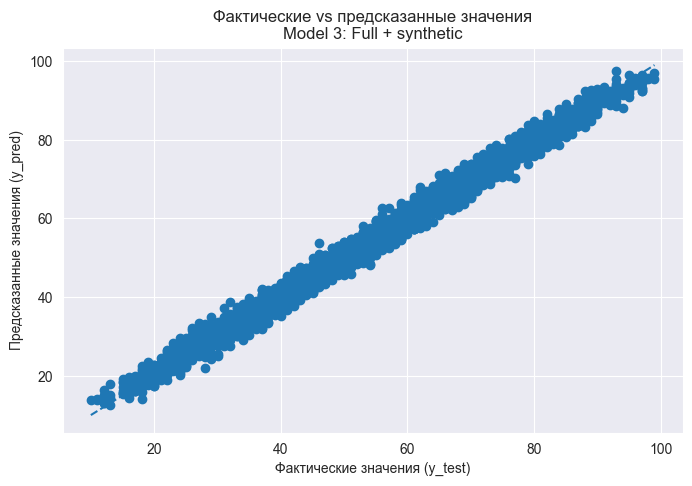

In [21]:
best_row = results_df.iloc[results_df['R2_test'].idxmax()]
best_model_name = best_row['Model']
best_features = feature_sets[best_model_name]

print('Лучшая модель по R^2 на тесте:', best_model_name)

X = df_scaled[best_features].values
y = df_scaled[target_col].values
X_train, X_test, y_train, y_test = train_test_split_manual(X, y, test_size=0.3, random_state=42)

best_model = LinearRegressionScratch()
best_model.fit(X_train, y_train)
y_pred_test = best_model.predict(X_test)

plt.figure()
plt.scatter(y_test, y_pred_test)
min_val = min(y_test.min(), y_pred_test.min())
max_val = max(y_test.max(), y_pred_test.max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle='--')
plt.xlabel('Фактические значения (y_test)')
plt.ylabel('Предсказанные значения (y_pred)')
plt.title(f'Фактические vs предсказанные значения\n{best_model_name}')
plt.grid(True)
plt.show()

График показывает, что предсказанные моделью значения почти полностью совпадают с фактическими: точки плотно лежат вдоль диагональной линии, что свидетельствует о высокой точности прогноза. Отклонения минимальны по всей области значений, поэтому модель адекватно описывает зависимость и хорошо обобщает данные. Это подтверждает высокое значение
$R^2$
 и говорит о том, что выбранный набор признаков позволяет максимально точно предсказывать показатель успеваемости.

## Шаг 10. Выводы

В ходе работы была проведена полноформатная обработка и анализ данных об успеваемости студентов, подготовлены различные наборы признаков и реализована линейная регрессия без использования сторонних библиотек. Сравнение трёх моделей показало, что один лишь показатель количества часов учёбы практически не объясняет итоговую успеваемость. Наиболее значимый вклад вносит академическая информация — предыдущие оценки и количество решённых практических заданий, что подтверждается высоким значением
$R^2$
 и стабильностью модели на тестовых данных. Расширение модели дополнительными признаками и синтетическим показателем не дало существенного улучшения качества, что означает, что основные зависимости уже полностью захватываются академическими факторами. В целом, линейная регрессия показала высокую точность для данного набора данных и позволила выявить ключевые факторы, определяющие результативность учебной деятельности.
